Core libraries imported.
Project directories ready.
Environment loaded. Model tiers:
  WEAK   -> gpt-4o-mini
  MID    -> gpt-5.4-mini
  STRONG -> gpt-5.4
Conditions: ['C1', 'C2', 'C3', 'C4', 'C5']
Datasets   : ['D1', 'D2', 'D2_fin', 'D3']
Grayscale plotting style configured.
Condition styles: {'C1': '0.15', 'C2': '0.3', 'C3': '0.45', 'C4': '0.6', 'C5': '0.75'}
Live check skipped (set RUN_LIVE_CHECK=True to test credentials).
Setup complete. Config snapshot saved.
Notebook 01 dependencies ready.
Mode: FULL | datasets=['D1', 'D2', 'D2_fin'] | limit=None | evidence=True | k_tables=8 k_cols=30
[D1] built 7238 contexts (1034 questions x 7 conditions).
[D2] built 3500 contexts (500 questions x 7 conditions).
[D2_fin] built 224 contexts (32 questions x 7 conditions).


n_tables  n_columns  context_tokens_est
dataset condition                                         
D1      C1              4.5       24.8               418.5
        C2              4.4       20.5               314.9
        C3              3.0       18.6               307.1
        C4              4.5       21.1               371.7
        C5_L1           4.5       20.5               363.6
        C5_L2           2.2       10.0               175.2
        C5_L3           2.2        5.1               105.6
D2      C1              7.3       76.9              3449.4
        C2              6.9       27.9               887.9
        C3              6.5       72.1              3332.1
        C4              7.3       62.3              2756.3
        C5_L1           7.3       30.1              1007.1
        C5_L2           4.7       22.2               590.2
        C5_L3           4.7       16.3               385.5
D2_fin  C1              8.0       55.0               804.6
        C2              8.0       30.0               497.4
        C3              6.3       46.2               674.8
        C4              8.0       39.1               671.3
        C5_L1           8.0       30.4               588.9
        C5_L2           4.4       18.5               328.8
        C5_L3           4.4       12.1               256.9

Saved figure: 01_context_size_by_condition.png, 01_context_size_by_condition.pdf


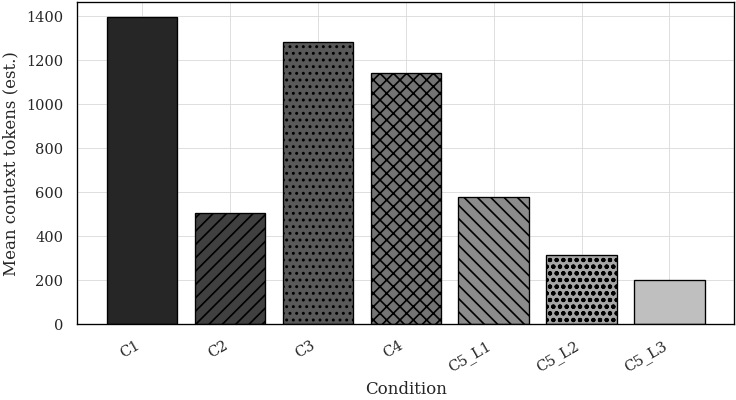

In [3]:
# ============================================================================
# 01_build_semantic_graph.ipynb
# ----------------------------------------------------------------------------
# Beyond Full-Schema Prompting: A Graph-based Semantic Layer for Text-to-SQL
#
# Purpose:
#   Turn each relational schema (from notebook 00b) into (a) an in-memory semantic
#   graph and (b) the per-condition schema CONTEXT strings fed to the LLM in
#   notebook 02. Builds all five conditions:
#     C1 Full Schema      - entire schema serialized (baseline)
#     C2 Vector-only      - top-k tables/columns by embedding similarity
#     C3 Graph-only       - graph traversal from full-text anchor matches
#     C4 Hybrid           - vector + full-text + graph traversal (Recall-oriented)
#     C5 Hybrid + Pruning - C4 then deterministic FK/join/column pruning (Precision)
#
#   The C4 vs C5 split is the paper's Section 8 contribution: probabilistic
#   retrieval (C4) vs deterministic pruning (C5).
#
#   SMOKE TEST: set SMOKE_TEST = True in Cell 2 to build a tiny slice first.
#   Anonymity: no filesystem paths are printed; only counts/summaries are shown.
#
# Inputs  : data/<dataset>/schema.json, data/<dataset>/questions.json
# Outputs : results/contexts/<dataset>/<condition>/<db_id>__<qid>.txt
#           results/contexts/<dataset>__context_meta.csv
#           results/contexts/schema_link_gold.csv
# ============================================================================


# %% [markdown]
# ## Cell 1 - Load shared configuration
# Pulls paths, conditions, the LLM/embedding client, and helpers from notebook 00.

# %%
%run 00_setup_and_config.ipynb


# %%
import re
import networkx as nx
from dataclasses import dataclass, field

print("Notebook 01 dependencies ready.")


# %% [markdown]
# ## Cell 2 - Run controls (smoke + pruning sweep + evidence-augmented retrieval)
# USE_EVIDENCE folds each question's 'evidence' hint into the retrieval query
# (embedding + anchor matching), which is critical for BIRD where column names
# are opaque. Top-k is widened to favor recall on large schemas.

# %%
SMOKE_TEST = False
SMOKE_N = 20
SMOKE_DATASETS = ["D1"]
FULL_DATASETS = ["D1", "D2", "D2_fin"]

# Retrieval hyper-parameters (widened for recall on large schemas).
K_TABLES = 8            # was 5
K_COLS = 30             # was 15
GRAPH_HOPS = 1

# Evidence-augmented retrieval (BIRD questions carry 'evidence' hints).
USE_EVIDENCE = True     # fold evidence into retrieval query + prompt context

# Pruning strength sweep.
PRUNE_LEVELS = [1, 2, 3]
PRUNE_KEEP_TOP_COLS = 12       # was 8; wider embedding-preserve at level 2
C5_CONDITIONS = {f"C5_L{lv}": lv for lv in PRUNE_LEVELS}
BUILD_CONDITIONS = ["C1", "C2", "C3", "C4"] + list(C5_CONDITIONS.keys())

if SMOKE_TEST:
    DATASETS_TO_BUILD = SMOKE_DATASETS
    BUILD_LIMIT = SMOKE_N
else:
    DATASETS_TO_BUILD = FULL_DATASETS
    BUILD_LIMIT = None

print(f"Mode: {'SMOKE' if SMOKE_TEST else 'FULL'} | datasets={DATASETS_TO_BUILD} "
      f"| limit={BUILD_LIMIT} | evidence={USE_EVIDENCE} "
      f"| k_tables={K_TABLES} k_cols={K_COLS}")


# %% [markdown]
# ## Cell 3 - Data structures for the semantic graph

# %%
@dataclass
class ColumnNode:
    table: str
    name: str
    dtype: str
    pk: bool = False
    desc: str = ""
    sample_values: list = field(default_factory=list)

    @property
    def qualified(self):
        return f"{self.table}.{self.name}"


@dataclass
class SchemaGraph:
    db_id: str
    graph: nx.MultiDiGraph
    columns: dict          # qualified name -> ColumnNode
    tables: list           # table names
    glossary: list         # glossary dicts
    join_patterns: list    # join-pattern dicts

    def table_columns(self, table):
        return [c for c in self.columns.values() if c.table == table]


# %% [markdown]
# ## Cell 4 - Build the semantic graph from a schema.json entry
# Nodes: Table, Column, Concept (glossary). Edges: HAS_COLUMN, FK, FK_TABLE, MAPS_TO.

# %%
def _load_schema_list(dataset_key):
    """Load and cache the full schema.json (a list of db dicts) for a dataset."""
    path = DATA_DIR / dataset_key / "schema.json"
    return json.loads(path.read_text(encoding="utf-8"))


def build_graph(schema_entry):
    """Construct a SchemaGraph from one schema.json db entry."""
    db_id = schema_entry["db_id"]
    G = nx.MultiDiGraph()
    columns = {}
    tables = list(schema_entry["tables"].keys())

    # Table + Column nodes
    for tname, tinfo in schema_entry["tables"].items():
        G.add_node(("table", tname), ntype="table", name=tname)
        for cname, cinfo in tinfo["columns"].items():
            col = ColumnNode(
                table=tname, name=cname,
                dtype=cinfo.get("type", "TEXT"),
                pk=bool(cinfo.get("pk", False)),
                desc=cinfo.get("desc", ""),
                sample_values=cinfo.get("sample_values", []),
            )
            columns[col.qualified] = col
            G.add_node(("column", col.qualified), ntype="column",
                       name=col.qualified, dtype=col.dtype, desc=col.desc)
            G.add_edge(("table", tname), ("column", col.qualified), etype="HAS_COLUMN")

    # Foreign-key edges (both directions for traversal convenience)
    for fk in schema_entry.get("foreign_keys", []):
        src, dst = fk["from"], fk["to"]
        if ("column", src) in G and ("column", dst) in G:
            G.add_edge(("column", src), ("column", dst), etype="FK")
            G.add_edge(("column", dst), ("column", src), etype="FK")
            st, dt = src.split(".")[0], dst.split(".")[0]
            G.add_edge(("table", st), ("table", dt), etype="FK_TABLE", on=f"{src}={dst}")
            G.add_edge(("table", dt), ("table", st), etype="FK_TABLE", on=f"{src}={dst}")

    # Concept (glossary) nodes + MAPS_TO edges
    for g in schema_entry.get("glossary", []):
        cid = ("concept", g["term"])
        G.add_node(cid, ntype="concept", name=g["term"],
                   definition=g.get("definition", ""))
        for target in g.get("maps_to", []):
            node = ("column", target) if target in columns else ("table", target)
            if node in G:
                G.add_edge(cid, node, etype="MAPS_TO")

    return SchemaGraph(
        db_id=db_id, graph=G, columns=columns, tables=tables,
        glossary=schema_entry.get("glossary", []),
        join_patterns=schema_entry.get("join_patterns", []),
    )


# %% [markdown]
# ## Cell 5 - Embeddings for vector retrieval (C2/C4/C5)
# Cached OpenAI embeddings. Each table/column is embedded once from a short
# natural-language descriptor (name + description + sample values).

# %%
EMBED_MODEL = "text-embedding-3-small"
EMBED_CACHE = CACHE_DIR / "embeddings"
EMBED_CACHE.mkdir(parents=True, exist_ok=True)


def _embed_cache_path(text):
    key = hashlib.sha256((EMBED_MODEL + "||" + text).encode("utf-8")).hexdigest()
    return EMBED_CACHE / f"{key}.json"


def embed_text(text):
    """Return a cached embedding vector for a single string."""
    p = _embed_cache_path(text)
    if p.exists():
        return json.loads(p.read_text(encoding="utf-8"))
    resp = _client.embeddings.create(model=EMBED_MODEL, input=text)
    vec = resp.data[0].embedding
    p.write_text(json.dumps(vec), encoding="utf-8")
    return vec


def _descriptor_for_column(col: ColumnNode):
    sv = ", ".join(str(v) for v in col.sample_values[:5])
    return f"table {col.table} column {col.name} ({col.dtype}). {col.desc}. examples: {sv}"


def _descriptor_for_table(sg: SchemaGraph, table):
    cols = ", ".join(c.name for c in sg.table_columns(table))
    return f"table {table} with columns: {cols}"


def cosine(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-12
    return float(np.dot(a, b) / denom)


# %% [markdown]
# ## Cell 6 - Retrieval primitives
# Full-text anchor matching, vector top-k, graph expansion, shortest join path.

# %%
def anchor_match(sg: SchemaGraph, question):
    """Deterministic full-text matches (tables/cols/glossary terms in the question)."""
    q = question.lower()
    q_tokens = set(re.findall(r"[a-z_]+", q))
    matched_tables, matched_cols = set(), set()

    for t in sg.tables:
        if t.lower() in q or t.lower().replace("_", " ") in q:
            matched_tables.add(t)
    for qn, col in sg.columns.items():
        name_tok = col.name.lower()
        if name_tok in q_tokens or name_tok.replace("_", " ") in q:
            matched_cols.add(qn)
            matched_tables.add(col.table)
    for g in sg.glossary:
        if g["term"].lower() in q:
            for target in g.get("maps_to", []):
                if target in sg.columns:
                    matched_cols.add(target)
                    matched_tables.add(target.split(".")[0])
                elif target in sg.tables:
                    matched_tables.add(target)
    return matched_tables, matched_cols


def vector_topk(sg: SchemaGraph, question, k_tables=K_TABLES, k_cols=K_COLS):
    """Embedding similarity retrieval over tables and columns."""
    qv = embed_text(question)

    tbl_scores = [(t, cosine(qv, embed_text(_descriptor_for_table(sg, t))))
                  for t in sg.tables]
    tbl_scores.sort(key=lambda x: x[1], reverse=True)
    top_tables = [t for t, _ in tbl_scores[:k_tables]]

    col_scores = [(qn, cosine(qv, embed_text(_descriptor_for_column(col))))
                  for qn, col in sg.columns.items()]
    col_scores.sort(key=lambda x: x[1], reverse=True)
    top_cols = [c for c, _ in col_scores[:k_cols]]

    tables = set(top_tables) | {c.split(".")[0] for c in top_cols}
    return tables, set(top_cols)


def graph_expand(sg: SchemaGraph, seed_tables, hops=GRAPH_HOPS):
    """Expand seed tables along FK_TABLE edges up to `hops`."""
    frontier = set(seed_tables)
    visited = set(seed_tables)
    for _ in range(hops):
        nxt = set()
        for t in frontier:
            node = ("table", t)
            if node not in sg.graph:
                continue
            for _, dst, data in sg.graph.out_edges(node, data=True):
                if data.get("etype") == "FK_TABLE" and dst[1] not in visited:
                    nxt.add(dst[1])
        visited |= nxt
        frontier = nxt
    return visited


def shortest_join_path(sg: SchemaGraph, tables):
    """Return (kept_tables, join_conditions) on shortest FK paths between tables."""
    tables = list(tables)
    join_conds, keep_tables = set(), set(tables)
    tbl_graph = nx.Graph()
    for u, v, data in sg.graph.edges(data=True):
        if data.get("etype") == "FK_TABLE":
            tbl_graph.add_edge(u[1], v[1], on=data.get("on", ""))
    for i in range(len(tables)):
        for j in range(i + 1, len(tables)):
            a, b = tables[i], tables[j]
            if a in tbl_graph and b in tbl_graph and nx.has_path(tbl_graph, a, b):
                path = nx.shortest_path(tbl_graph, a, b)
                keep_tables.update(path)
                for x, y in zip(path[:-1], path[1:]):
                    on = tbl_graph[x][y].get("on", "")
                    if on:
                        join_conds.add(on)
    return keep_tables, sorted(join_conds)


# %% [markdown]
# ## Cell 7 - Deterministic pruning with adjustable strength (paper Section 8.2)
# level 1: drop FK-isolated tables only (columns untouched).
# level 2: + minimize to join-path tables; project columns but PRESERVE the top
#          embedding-similar columns so semantically-relevant gold cols survive.
# level 3: aggressive - strict token/type projection (original C5 behavior).
# Uses graph facts + question tokens; level 2 also uses cached embeddings.

# %%
def extract_literals(question):
    strings = re.findall(r"'([^']+)'|\"([^\"]+)\"", question)
    strings = [s1 or s2 for s1, s2 in strings]
    numbers = re.findall(r"\b\d+(?:\.\d+)?\b", question)
    return strings, numbers


def _is_fk_column(sg: SchemaGraph, qualified):
    node = ("column", qualified)
    if node not in sg.graph:
        return False
    for _, _, d in sg.graph.out_edges(node, data=True):
        if d.get("etype") == "FK":
            return True
    for _, _, d in sg.graph.in_edges(node, data=True):
        if d.get("etype") == "FK":
            return True
    return False


def _embedding_top_cols(sg: SchemaGraph, question, candidate_cols, top_k):
    """Return the top_k candidate columns by embedding similarity to the question."""
    if not candidate_cols or top_k <= 0:
        return set()
    qv = embed_text(question)
    scored = []
    for qn in candidate_cols:
        col = sg.columns.get(qn)
        if col is None:
            continue
        scored.append((qn, cosine(qv, embed_text(_descriptor_for_column(col)))))
    scored.sort(key=lambda x: x[1], reverse=True)
    return {qn for qn, _ in scored[:top_k]}


def deterministic_prune(sg: SchemaGraph, cand_tables, cand_cols, question,
                        level=3, keep_top_cols=PRUNE_KEEP_TOP_COLS):
    """
    Prune the C4 candidate set at a given strength `level` (1/2/3).
    Returns (kept_tables, kept_cols, join_conds).
    """
    q = question.lower()
    q_tokens = set(re.findall(r"[a-z_]+", q))
    strings, numbers = extract_literals(question)
    anchor_tables, anchor_cols = anchor_match(sg, question)

    # ---- Table pruning ----
    if level >= 2:
        # Restrict to validated join-path tables between anchors (within candidates).
        seed = anchor_tables if anchor_tables else set(cand_tables)
        keep_tables, join_conds = shortest_join_path(sg, seed)
        keep_tables = (keep_tables & set(cand_tables)) | anchor_tables
        if not keep_tables:
            keep_tables = set(cand_tables)
    else:
        # Level 1: drop only FK-isolated tables (no connection to any anchor/candidate).
        keep_tables, join_conds = shortest_join_path(sg, set(cand_tables))
        keep_tables = keep_tables & set(cand_tables)
        if not keep_tables:
            keep_tables = set(cand_tables)

    # ---- Column pruning ----
    if level <= 1:
        # Keep all candidate columns of surviving tables (recall-preserving).
        keep_cols = {qn for qn in cand_cols if qn.split(".")[0] in keep_tables}
    else:
        # Token/anchor/key-relevant columns...
        keep_cols = set()
        for qn in cand_cols:
            if qn.split(".")[0] not in keep_tables:
                continue
            col = sg.columns[qn]
            name_tok = col.name.lower()
            if (qn in anchor_cols or col.pk or _is_fk_column(sg, qn)
                    or name_tok in q_tokens or name_tok.replace("_", " ") in q):
                keep_cols.add(qn)

        if level == 2:
            # ...PLUS embedding-preserved columns so semantically-relevant gold
            # columns that don't lexically appear in the question survive.
            pool = [qn for qn in cand_cols if qn.split(".")[0] in keep_tables]
            keep_cols |= _embedding_top_cols(sg, question, pool, keep_top_cols)

        # Always retain keys for join expressibility.
        for t in keep_tables:
            for col in sg.table_columns(t):
                if col.pk or _is_fk_column(sg, col.qualified):
                    keep_cols.add(col.qualified)

        # Level 3 only: numeric-only question -> drop clear text-only non-key cols.
        if level >= 3 and numbers and not strings:
            drop = {qn for qn in keep_cols
                    if sg.columns[qn].dtype.upper() in {"TEXT", "VARCHAR", "CHAR"}
                    and qn not in anchor_cols
                    and not sg.columns[qn].pk and not _is_fk_column(sg, qn)}
            keep_cols -= drop

    return keep_tables, keep_cols, join_conds


# %% [markdown]
# ## Cell 8 - Serialize a schema subset into an LLM context string

# %%
def render_context(sg: SchemaGraph, tables, cols, join_conds=None,
                   include_glossary=True, include_samples=True, include_joins=True):
    """Serialize a schema subset to a stable string for the LLM prompt."""
    tables = sorted(tables)
    lines = [f"-- Database: {sg.db_id}", "-- Schema (relevant subset):"]

    for t in tables:
        lines.append(f"\nTABLE {t} (")
        tcols = [c for c in sg.table_columns(t)
                 if (cols is None or c.qualified in cols or c.pk)]
        if not tcols:
            tcols = [c for c in sg.table_columns(t) if c.pk] or sg.table_columns(t)[:1]
        for c in tcols:
            tag = " PRIMARY KEY" if c.pk else ""
            desc = f"  -- {c.desc}" if c.desc else ""
            samples = ""
            if include_samples and c.sample_values:
                sv = ", ".join(str(v) for v in c.sample_values[:3])
                samples = f" [e.g., {sv}]"
            lines.append(f"    {c.name} {c.dtype}{tag},{desc}{samples}")
        lines.append(")")

    if include_glossary and sg.glossary:
        relevant = [g for g in sg.glossary
                    if any(m.split('.')[0] in tables for m in g.get("maps_to", []))]
        if relevant:
            lines.append("\n-- Business glossary:")
            for g in relevant:
                lines.append(f"--   {g['term']}: {g.get('definition','')} "
                             f"-> {', '.join(g.get('maps_to', []))}")

    if include_joins and join_conds:
        lines.append("\n-- Suggested join paths:")
        for j in join_conds:
            lines.append(f"--   {j}")

    return "\n".join(lines)


# %% [markdown]
# ## Cell 9 - Per-condition context builder (evidence-augmented)
# The retrieval query is question (+ evidence when USE_EVIDENCE). Evidence is also
# appended to the rendered context so the generator can use the same hint.

# %%
def _retrieval_query(question, evidence):
    if USE_EVIDENCE and evidence:
        return f"{question}\nHint: {evidence}"
    return question


def build_context(sg: SchemaGraph, question, condition, evidence=""):
    rq = _retrieval_query(question, evidence)   # used for embedding + anchors

    if condition == "C1":
        tables = set(sg.tables)
        cols = set(sg.columns.keys())
        join_conds = sorted({d["on"] for _, _, d in sg.graph.edges(data=True)
                             if d.get("etype") == "FK_TABLE" and "on" in d})
        ctx = render_context(sg, tables, cols, join_conds)

    elif condition == "C2":
        tables, cols = vector_topk(sg, rq)
        ctx = render_context(sg, tables, cols, None)

    elif condition == "C3":
        a_tables, _ = anchor_match(sg, rq)
        seed = a_tables if a_tables else set(list(sg.tables)[:1])
        tables = graph_expand(sg, seed)
        _, join_conds = shortest_join_path(sg, tables)
        cols = {c.qualified for t in tables for c in sg.table_columns(t)}
        ctx = render_context(sg, tables, cols, join_conds)

    elif condition == "C4":
        v_tables, v_cols = vector_topk(sg, rq)
        a_tables, a_cols = anchor_match(sg, rq)
        tables = graph_expand(sg, v_tables | a_tables)
        cols = v_cols | a_cols | {c.qualified for t in a_tables
                                  for c in sg.table_columns(t)}
        _, join_conds = shortest_join_path(sg, tables)
        ctx = render_context(sg, tables, cols, join_conds)

    elif condition.startswith("C5"):
        level = int(condition.split("_L")[-1]) if "_L" in condition else 3
        v_tables, v_cols = vector_topk(sg, rq)
        a_tables, a_cols = anchor_match(sg, rq)
        cand_tables = graph_expand(sg, v_tables | a_tables)
        cand_cols = v_cols | a_cols
        tables, cols, join_conds = deterministic_prune(
            sg, cand_tables, cand_cols, rq, level=level)
        ctx = render_context(sg, tables, cols, join_conds)

    else:
        raise ValueError(f"Unknown condition: {condition}")

    # Append evidence to the context so the generator sees the same hint.
    if USE_EVIDENCE and evidence:
        ctx = ctx + f"\n\n-- External knowledge (evidence):\n--   {evidence}"

    return ctx, {"tables": sorted(tables), "columns": sorted(cols)}


# %% [markdown]
# ## Cell 10 - Build and persist contexts (passes evidence to the builder)

# %%
def count_tokens_approx(text):
    return max(1, int(len(text) / 4))


def build_all_contexts(dataset_key, limit=None):
    questions = json.loads(
        (DATA_DIR / dataset_key / "questions.json").read_text(encoding="utf-8"))
    if limit:
        questions = questions[:limit]

    schema_list = _load_schema_list(dataset_key)
    schema_by_db = {s["db_id"]: s for s in schema_list}
    graph_cache = {}

    rows, gold_rows = [], []
    for q in questions:
        db_id = q["db_id"]
        if db_id not in schema_by_db:
            continue
        if db_id not in graph_cache:
            graph_cache[db_id] = build_graph(schema_by_db[db_id])
        sg = graph_cache[db_id]
        evidence = q.get("evidence", "")           # <- pull evidence

        gold_rows.append({
            "dataset": dataset_key, "qid": q["qid"], "db_id": db_id,
            "gold_tables": "|".join(q.get("gold_tables", [])),
            "gold_columns": "|".join(q.get("gold_columns", [])),
        })

        for cond in BUILD_CONDITIONS:
            ctx, sel = build_context(sg, q["question"], cond, evidence=evidence)  # <- pass
            out_dir = CONTEXTS_DIR / dataset_key / cond
            out_dir.mkdir(parents=True, exist_ok=True)
            fpath = out_dir / f"{db_id}__{q['qid']}.txt"
            fpath.write_text(ctx, encoding="utf-8")

            rows.append({
                "dataset": dataset_key, "qid": q["qid"], "db_id": db_id,
                "condition": cond,
                "n_tables": len(sel["tables"]),
                "n_columns": len(sel["columns"]),
                "context_tokens_est": count_tokens_approx(ctx),
                "selected_tables": "|".join(sel["tables"]),
                "selected_columns": "|".join(sel["columns"]),
                "context_path": str(fpath.relative_to(PROJECT_ROOT)),
            })

    meta_df = pd.DataFrame(rows)
    meta_df.to_csv(CONTEXTS_DIR / f"{dataset_key}__context_meta.csv", index=False)

    gold_out = CONTEXTS_DIR / "schema_link_gold.csv"
    gold_df = pd.DataFrame(gold_rows)
    if gold_out.exists():
        prev = pd.read_csv(gold_out)
        prev = prev[prev["dataset"] != dataset_key]
        gold_df = pd.concat([prev, gold_df], ignore_index=True)
    gold_df.to_csv(gold_out, index=False)

    print(f"[{dataset_key}] built {len(meta_df)} contexts "
          f"({meta_df['qid'].nunique()} questions x {len(BUILD_CONDITIONS)} conditions).")
    return meta_df


# %% [markdown]
# ## Cell 11 - Run the builder

# %%
all_meta = []
for ds in DATASETS_TO_BUILD:
    if (DATA_DIR / ds / "questions.json").exists() and \
       (DATA_DIR / ds / "schema.json").exists():
        all_meta.append(build_all_contexts(ds, limit=BUILD_LIMIT))
    else:
        print(f"[skip] {ds}: schema.json/questions.json missing.")

if all_meta:
    context_meta = pd.concat(all_meta, ignore_index=True)
    display(context_meta.groupby(["dataset", "condition"])
            [["n_tables", "n_columns", "context_tokens_est"]].mean().round(1))
else:
    print("Nothing built.")


# %% [markdown]
# ## Cell 12 - Sanity figure: context size across conditions incl. pruning levels
# Expect C1 > C4 > C5_L1 > C5_L2 > C5_L3 (monotone shrink with strength).

# %%
if all_meta:
    order = [c for c in BUILD_CONDITIONS]
    fig, ax = plt.subplots(figsize=(6.4, 3.6))
    plot_df = (context_meta.groupby("condition")["context_tokens_est"]
               .mean().reindex(order))
    grays = gray_palette(len(order))
    bars = ax.bar(range(len(plot_df)), plot_df.values, color=grays,
                  edgecolor="black", linewidth=0.8)
    for i, b in enumerate(bars):
        b.set_hatch(HATCHES[i % len(HATCHES)])
    ax.set_xticks(range(len(plot_df)))
    ax.set_xticklabels(plot_df.index, rotation=30, ha="right")
    ax.set_ylabel("Mean context tokens (est.)")
    ax.set_xlabel("Condition")
    save_figure(fig, "01_context_size_by_condition")
    plt.show()

In [2]:
# %% [markdown]
# ## Diagnostic - check whether BIRD questions carry 'evidence'
# We rely on the evidence field to boost retrieval on D2. Confirm it exists and
# is non-empty for a sample of D2 questions. No paths printed.

# %%
_d2q = json.loads((DATA_DIR / "D2" / "questions.json").read_text(encoding="utf-8"))
_has_ev = [bool(q.get("evidence", "").strip()) for q in _d2q]
print(f"D2 questions: {len(_d2q)}")
print(f"  with non-empty evidence: {sum(_has_ev)} ({100*sum(_has_ev)/len(_d2q):.0f}%)")
# show 3 examples
_shown = 0
for q in _d2q:
    ev = q.get("evidence", "").strip()
    if ev:
        print(f"\n  Q: {q['question'][:90]}")
        print(f"  evidence: {ev[:140]}")
        _shown += 1
    if _shown >= 3:
        break

D2 questions: 500
  with non-empty evidence: 498 (100%)

  Q: What is the ratio of customers who pay in EUR against customers who pay in CZK?
  evidence: ratio of customers who pay in EUR against customers who pay in CZK = count(Currency = 'EUR') / count(Currency = 'CZK').

  Q: In 2012, who had the least consumption in LAM?
  evidence: Year 2012 can be presented as Between 201201 And 201212; The first 4 strings of the Date values in the yearmonth table can represent year.

  Q: What was the average monthly consumption of customers in SME for the year 2013?
  evidence: Average Monthly consumption = AVG(Consumption) / 12; Year 2013 can be presented as Between 201301 And 201312; The first 4 strings of the Dat
